<a href="https://colab.research.google.com/github/dishanayak144/Housing-Prices-Project/blob/main/BRAHMAPUR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn import model_selection
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
bam_buy= pd.read_excel('/content/drive/MyDrive/EAST INDIA DATA/BAM DATAA.xlsx', sheet_name='RES BUY')
bam_rent= pd.read_excel('/content/drive/MyDrive/EAST INDIA DATA/BAM DATAA.xlsx', sheet_name='RES RENT')


In [ ]:
bam_buy.head()


,tupleNew__locationName,RESALE,tupleNew__bOld,tupleNew__priceValWrap,Text After Delimiter,PER SQFT PRICE,AREA,PROPERTY TYPE,STATUS,descPtag_undefined,OWNER_TYPE,PRICE,HOUSE/PLOT,BHK
0,"Harsha Vihar, Berhampur",1,4 Bedroom House,1.77,10000000,8850,2000,4 BHK,Ready To Move,The property stands over a plot measuring 40 f...,Owner,17700000,1,4
1,"Housing Board Colony, Berhampur",1,Residential land / Plot,1.20,10000000,9090,1320,Plot/Land,Ready To Move,Shopcum residential allotment by bda,Owner,12000000,0,0
2,"Haladiapadar, Berhampur",1,Residential land / Plot,55.00,100000,3055,1800,Plot/Land,Ready To Move,An excellent opportunity to own a property 180...,Owner,5500000,0,0
3,"Ankuli, Berhampur",1,2 Bedroom House,51.00,100000,5666,900,2 BHK,Ready To Move,Well constructed morden house with interior no...,Owner,5100000,1,2
4,industrial / Residential Plot,1,Residential land / Plot,9.00,100000,1000,900,Plot/Land,Ready To Move,Bhatakumarada industrial/ residential layout S...,Owner,900000,0,0


In [ ]:
bam_rent.head()


,tupleNew__locationName,tupleNew__bOld,PRICE,ADVANCE,ADV,AREA,BHK,ADD. INFO,AMENITIES,OWNER_TYPE
0,Niwas Enclave,2 BHK Flat for rent,8700.0,"+ Deposit ₹17,400",1,725.0,2.0,Newly renovated painted flat with car parking ...,1,Owner
1,"Bank Colony, Berhampur",3 Bedroom House for rent,20000.0,NO ADV,0,2500.0,3.0,Spacious rooms. Big central hall .25 ft space ...,1,Owner
2,ananta niwas defence colony,2 BHK Flat for rent,8000.0,+ Deposit 2 months rent,1,800.0,2.0,"2bhk flat for rent in ananta niwas, defence co...",1,Owner
3,Raja Rani Delight Homes,2 BHK Flat for rent,9000.0,"+ Deposit ₹30,000",1,1000.0,2.0,I want to rent out a 2 bhk apartment available...,1,Owner
4,"Sriramnagar, Berhampur",3 Bedroom House for rent,5000.0,+ Deposit 3 months rent,1,700.0,3.0,"Newly built property in a good area, with good...",1,Owner


In [ ]:
bam_buy.columns


Index(['tupleNew__locationName', 'RESALE', 'tupleNew__bOld',
       'tupleNew__priceValWrap', 'Text After Delimiter', 'PER SQFT PRICE',
       'AREA', 'PROPERTY TYPE', 'STATUS', 'descPtag_undefined', 'OWNER_TYPE',
       'PRICE', 'HOUSE/PLOT', 'BHK'],
      dtype='object')

In [ ]:
bam_rent.columns

Index(['tupleNew__locationName', 'tupleNew__bOld', 'PRICE', 'ADVANCE', 'ADV',
       'AREA', 'BHK', 'ADD. INFO', 'AMENITIES', 'OWNER_TYPE'],
      dtype='object')

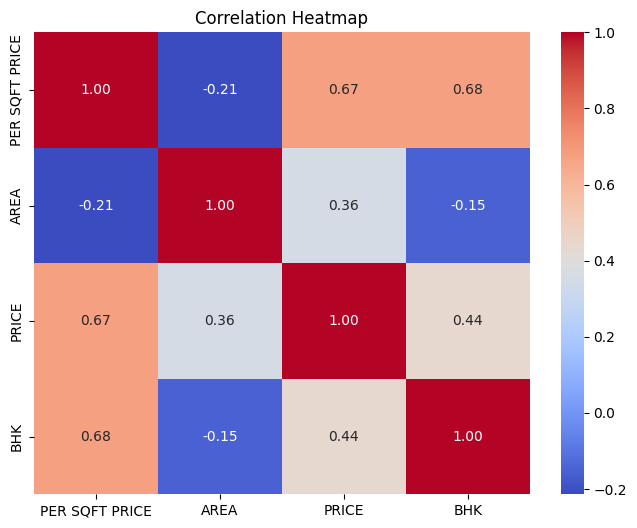


Correlation Table:


,PER SQFT PRICE,AREA,PRICE,BHK
PER SQFT PRICE,1.000000,-0.213756,0.674780,0.675906
AREA,-0.213756,1.000000,0.359110,-0.153996
PRICE,0.674780,0.359110,1.000000,0.436785
BHK,0.675906,-0.153996,0.436785,1.000000


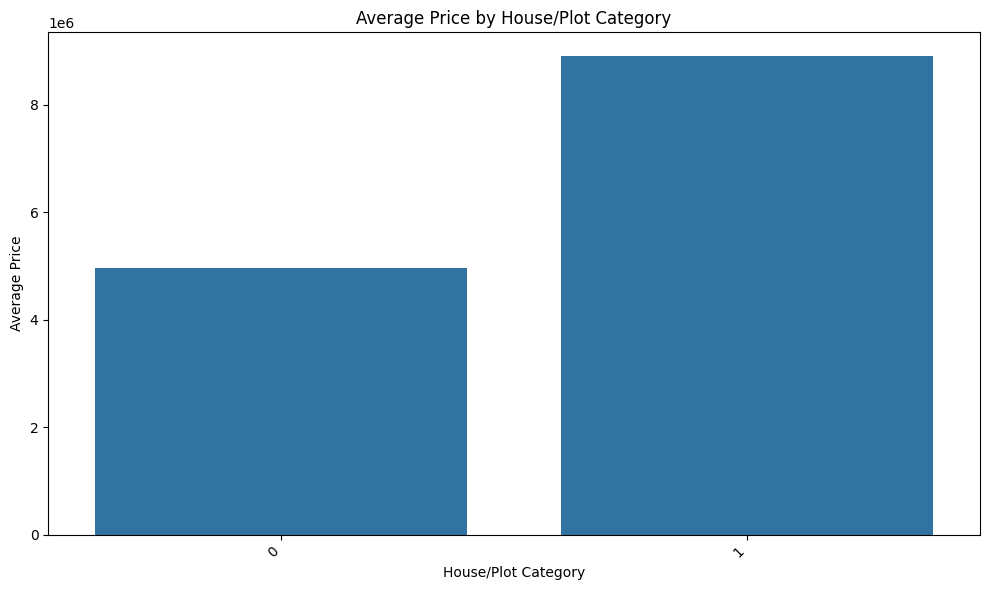

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd



# Select the columns of interest
cols = ['PER SQFT PRICE', 'AREA', 'PRICE', 'BHK']
data = bam_buy[cols]

# Calculate the correlation matrix
correlation_matrix = data.corr()

# Create the heatmap
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Display the correlation table
print("\nCorrelation Table:")
display(correlation_matrix)

# Calculate the average price for each category
avg_price_by_category = bam_buy.groupby('HOUSE/PLOT')['PRICE'].mean().reset_index()

# Create the bar graph
plt.figure(figsize=(10, 6))
sns.barplot(x='HOUSE/PLOT', y='PRICE', data=avg_price_by_category)
plt.title('Average Price by House/Plot Category')
plt.xlabel('House/Plot Category')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

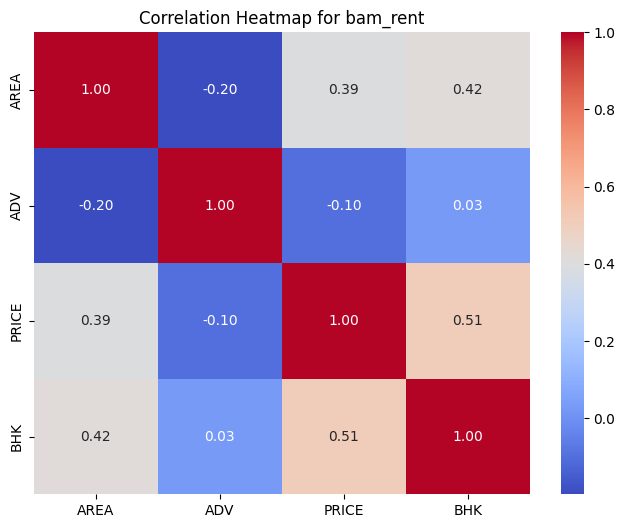


Correlation Table:


,AREA,ADV,PRICE,BHK
AREA,1.000000,-0.196768,0.393904,0.418101
ADV,-0.196768,1.000000,-0.100452,0.030576
PRICE,0.393904,-0.100452,1.000000,0.508472
BHK,0.418101,0.030576,0.508472,1.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Select the columns of interest
cols = ['AREA', 'ADV', 'PRICE', 'BHK']
data = bam_rent[cols]

# Fill NaN values with the mean of each column
for col in cols:
    bam_rent[col] = bam_rent[col].fillna(bam_rent[col].mean())

# Calculate the correlation matrix
correlation_matrix = data.corr()

# Create the heatmap
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap for bam_rent')
plt.show()

# Display the correlation table
print("\nCorrelation Table:")
display(correlation_matrix)


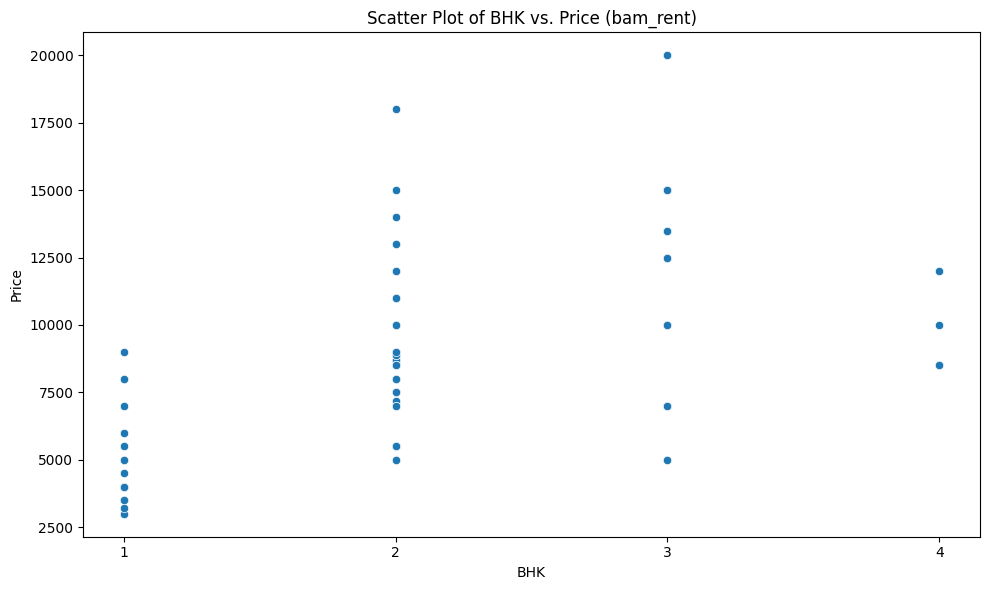

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert 'BHK' column to integers
bam_rent['BHK'] = bam_rent['BHK'].astype(int)

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='BHK', y='PRICE', data=bam_rent)
plt.title('Scatter Plot of BHK vs. Price (bam_rent)')
plt.xlabel('BHK')
plt.ylabel('Price')
plt.xticks(range(int(bam_rent['BHK'].min()), int(bam_rent['BHK'].max()) + 1)) # Set x-axis ticks to integers
plt.tight_layout()
plt.show()

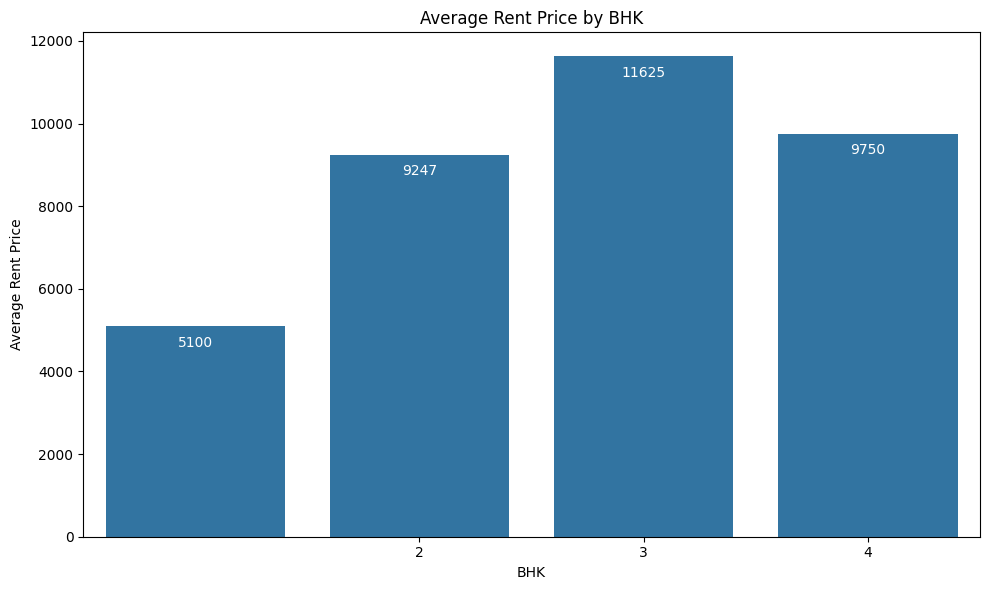

In [ ]:


# Calculate the average price for each BHK category
avg_price_by_bhk = bam_rent.groupby('BHK')['PRICE'].mean().reset_index()

# Create the bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='BHK', y='PRICE', data=avg_price_by_bhk)
plt.title('Average Rent Price by BHK')
plt.xlabel('BHK')
plt.ylabel('Average Rent Price')
plt.xticks(range(int(bam_rent['BHK'].min()), int(bam_rent['BHK'].max())))  # Set x-axis ticks to integers

# Add data labels inside bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, -12),
                textcoords = 'offset points',
                color='white')

plt.tight_layout()
plt.show()